<a href="https://colab.research.google.com/github/sgarciarod/alzheimers-classification-shallow-vs-deep-nn/blob/main/02_adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADALINE: Adaptive Linear Neuron

## 1. Introducción Teórica

### Historia y contexto
**ADALINE** (Adaptive Linear Neuron) fue desarrollado por **Bernard Widrow** y su estudiante **Ted Hoff** en **1960** en la Universidad de Stanford. Fue publicado como un informe técnico y representó un avance significativo respecto al Perceptrón de Rosenblatt (1958).

A diferencia del Perceptrón, ADALINE introdujo el concepto de **aprendizaje continuo basado en minimización de error**, sentando las bases para muchas redes neuronales modernas.

---

### Diferencias clave con el Perceptrón

| Característica | Perceptrón | ADALINE |
|---|---|---|
| Función de activación (entrenamiento) | Escalón (Heaviside) | **Lineal (identidad)** |
| Función de activación (predicción) | Escalón | Escalón |
| Función de costo | Número de errores | **MSE (Error Cuadrático Medio)** |
| Regla de actualización | Regla del Perceptrón | **Regla Delta / LMS** |
| Garantía de convergencia | Solo si linealmente separable | Converge al mínimo (si η apropiado) |

La diferencia fundamental: durante el **entrenamiento**, ADALINE usa la **salida lineal** (antes de la función escalón) para calcular el error y actualizar los pesos, lo que permite usar cálculo diferencial.

---

### La Regla Delta / LMS (Least Mean Squares)

La actualización de pesos en ADALINE sigue la **Regla Delta** (también llamada regla LMS o regla de Widrow-Hoff):

$$\mathbf{w} = \mathbf{w} + \eta (y - z) \mathbf{x}$$

Donde:
- $\mathbf{w}$ = vector de pesos
- $\eta$ = tasa de aprendizaje (learning rate)
- $y$ = etiqueta verdadera
- $z = \mathbf{w} \cdot \mathbf{x} + b$ = **salida lineal** (antes de la función escalón)
- $\mathbf{x}$ = vector de características de entrada

---

### Descenso de Gradiente y su rol en ADALINE

ADALINE minimiza una **función de costo diferenciable** mediante **descenso de gradiente**:

$$J(\mathbf{w}) = \frac{1}{2} \sum_i (y^{(i)} - z^{(i)})^2 = \frac{1}{2} \text{MSE}$$

El gradiente de $J$ respecto a los pesos es:

$$\frac{\partial J}{\partial w_j} = -\sum_i (y^{(i)} - z^{(i)}) x_j^{(i)}$$

Por tanto, la actualización de pesos es:

$$\Delta \mathbf{w} = -\eta \nabla J(\mathbf{w}) = \eta \sum_i (y^{(i)} - z^{(i)}) \mathbf{x}^{(i)}$$

Existen dos variantes principales:
1. **Batch Gradient Descent (GD)**: Actualiza los pesos usando **todos** los ejemplos de entrenamiento en cada época.
2. **Stochastic Gradient Descent (SGD)**: Actualiza los pesos usando **un ejemplo a la vez**, de forma aleatoria.

---

### Función de Costo: MSE

El **Error Cuadrático Medio** (MSE) es una función convexa, lo que garantiza la existencia de un **mínimo global**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - z^{(i)})^2$$

Esta propiedad de convexidad hace que ADALINE sea más robusto y predecible en su convergencia que el Perceptrón.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(1)

class AdalineGD:
    """ADALINE con Descenso de Gradiente por lotes (Batch Gradient Descent)."""

    def __init__(self, eta=0.01, n_iter=50):
        self.eta = eta        # tasa de aprendizaje
        self.n_iter = n_iter  # número de épocas

    def fit(self, X, y):
        """Entrenar ADALINE con descenso de gradiente por lotes."""
        self.w_ = np.zeros(1 + X.shape[1])  # 1 + n_features: índice 0 = sesgo (bias)
        self.cost_ = []  # costo MSE por época

        for _ in range(self.n_iter):
            output = self.activation(X)    # salida lineal
            errors = (y - output)           # errores
            self.w_[1:] += self.eta * X.T.dot(errors)  # actualizar pesos
            self.w_[0] += self.eta * errors.sum()        # actualizar sesgo
            cost = (errors**2).sum() / 2.0               # calcular MSE/2
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calcular la entrada neta."""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Función de activación lineal (identidad)."""
        return self.net_input(X)

    def predict(self, X):
        """Predecir etiqueta usando función escalón después del entrenamiento."""
        return np.where(self.activation(X) >= 0.5, 1, -1)


class AdalineSGD:
    """ADALINE con Descenso de Gradiente Estocástico (Stochastic Gradient Descent)."""

    def __init__(self, eta=0.01, n_iter=15, shuffle=True, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.shuffle = shuffle
        self.random_state = random_state
        self.w_initialized = False

    def fit(self, X, y):
        """Entrenar ADALINE con descenso de gradiente estocástico."""
        self._initialize_weights(X.shape[1])
        self.cost_ = []

        for _ in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            cost = []
            for xi, target in zip(X, y):
                cost.append(self._update_weights(xi, target))
            avg_cost = sum(cost) / len(y)  # costo promedio por época
            self.cost_.append(avg_cost)
        return self

    def partial_fit(self, X, y):
        """Ajuste parcial sin reinicializar pesos (para aprendizaje online)."""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        """Mezclar los datos de entrenamiento."""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        """Inicializar pesos con valores pequeños aleatorios."""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=1 + m)  # 1 extra para el sesgo (bias w0)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Actualizar pesos usando la regla delta."""
        output = self.activation(xi)
        error = (target - output)
        self.w_[1:] += self.eta * xi.dot(error)  # actualizar pesos de características
        self.w_[0] += self.eta * error              # actualizar sesgo (bias w0)
        cost = 0.5 * error**2
        return cost

    def net_input(self, X):
        """Calcular la entrada neta."""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Función de activación lineal (identidad)."""
        return self.net_input(X)

    def predict(self, X):
        """Predecir etiqueta usando función escalón."""
        return np.where(self.activation(X) >= 0.5, 1, -1)

print("Clases AdalineGD y AdalineSGD definidas correctamente.")

Clases AdalineGD y AdalineSGD definidas correctamente.


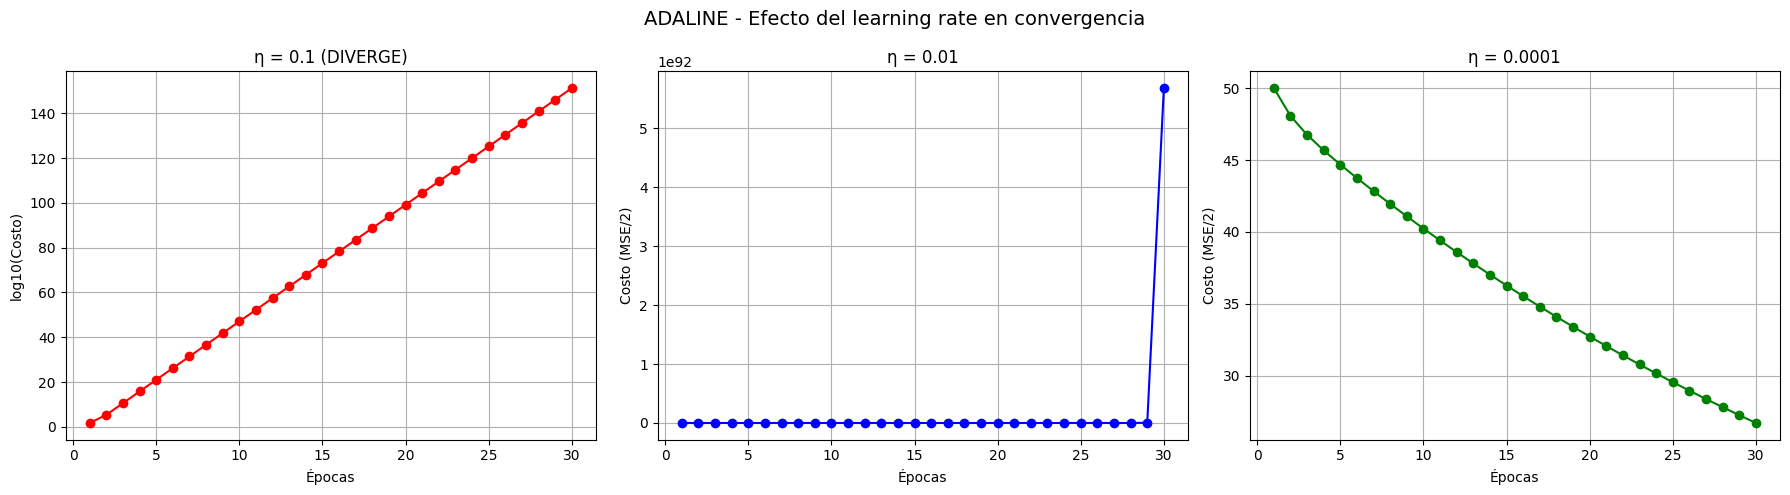

In [ ]:
# Cargar dataset Iris
iris = load_iris()
X = iris.data[:100, [0, 2]]  # sepal length, petal length
y = iris.target[:100]
y = np.where(y == 0, -1, 1)

# Probar diferentes tasas de aprendizaje
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

learning_rates = [0.1, 0.01, 0.0001]
colors = ['red', 'blue', 'green']

for i, (lr, color) in enumerate(zip(learning_rates, colors)):
    ada = AdalineGD(eta=lr, n_iter=30)
    ada.fit(X, y)

    if lr == 0.1:
        # diverge - limitar para visualización
        costs_to_plot = [min(c, 1e6) for c in ada.cost_]
        axes[i].plot(range(1, len(ada.cost_) + 1), np.log10(np.abs(ada.cost_) + 1),
                    marker='o', color=color)
        axes[i].set_title(f'η = {lr} (DIVERGE)')
    else:
        axes[i].plot(range(1, len(ada.cost_) + 1), ada.cost_,
                    marker='o', color=color)
        axes[i].set_title(f'η = {lr}')

    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('Costo (MSE/2)' if lr != 0.1 else 'log10(Costo)')
    axes[i].grid(True)

plt.suptitle('ADALINE - Efecto del learning rate en convergencia', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/adaline_learning_rates.png', dpi=100, bbox_inches='tight')
plt.show()

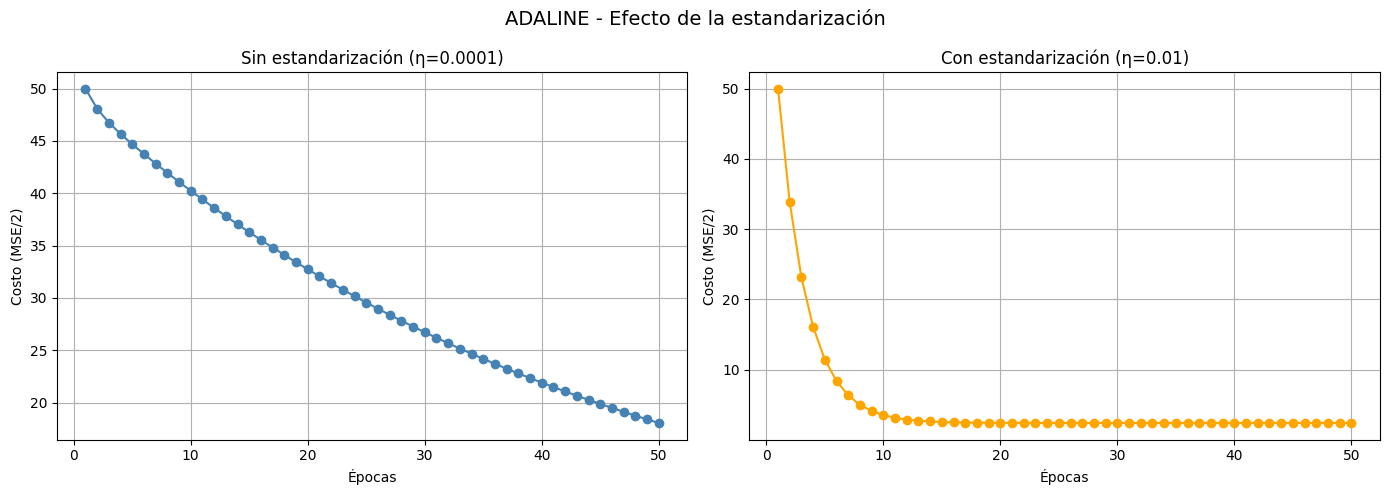

Costo final sin estandarización: 18.0523
Costo final con estandarización: 2.4302


In [ ]:
# Sin estandarización
ada_no_std = AdalineGD(eta=0.0001, n_iter=50)
ada_no_std.fit(X, y)

# Con estandarización
sc = StandardScaler()
X_std = sc.fit_transform(X)

ada_std = AdalineGD(eta=0.01, n_iter=50)
ada_std.fit(X_std, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ada_no_std.cost_) + 1), ada_no_std.cost_,
            marker='o', color='steelblue')
axes[0].set_title('Sin estandarización (η=0.0001)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Costo (MSE/2)')
axes[0].grid(True)

axes[1].plot(range(1, len(ada_std.cost_) + 1), ada_std.cost_,
            marker='o', color='orange')
axes[1].set_title('Con estandarización (η=0.01)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Costo (MSE/2)')
axes[1].grid(True)

plt.suptitle('ADALINE - Efecto de la estandarización', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/adaline_standardization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Costo final sin estandarización: {ada_no_std.cost_[-1]:.4f}")
print(f"Costo final con estandarización: {ada_std.cost_[-1]:.4f}")

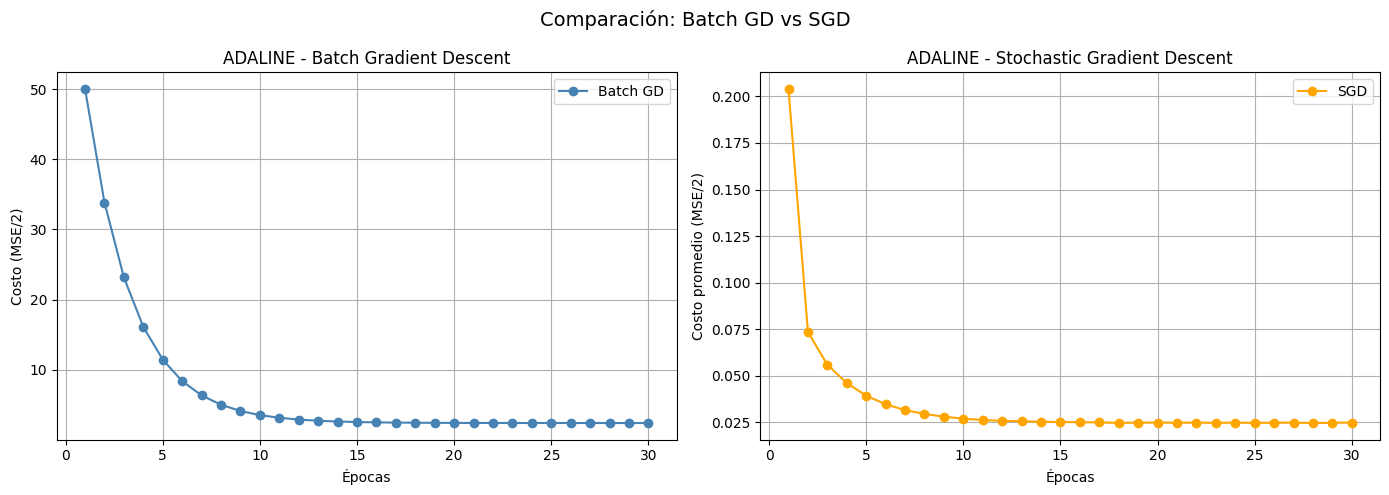

Costo final Batch GD: 2.4304
Costo final SGD:      0.0249


In [ ]:
# Datos estandarizados
sc = StandardScaler()
X_std = sc.fit_transform(X)

# Batch Gradient Descent
ada_gd = AdalineGD(eta=0.01, n_iter=30)
ada_gd.fit(X_std, y)

# Stochastic Gradient Descent
ada_sgd = AdalineSGD(eta=0.01, n_iter=30, random_state=1)
ada_sgd.fit(X_std, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ada_gd.cost_) + 1), ada_gd.cost_,
            marker='o', color='steelblue', label='Batch GD')
axes[0].set_title('ADALINE - Batch Gradient Descent')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Costo (MSE/2)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, len(ada_sgd.cost_) + 1), ada_sgd.cost_,
            marker='o', color='orange', label='SGD')
axes[1].set_title('ADALINE - Stochastic Gradient Descent')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Costo promedio (MSE/2)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Comparación: Batch GD vs SGD', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/adaline_batch_vs_sgd.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Costo final Batch GD: {ada_gd.cost_[-1]:.4f}")
print(f"Costo final SGD:      {ada_sgd.cost_[-1]:.4f}")

             Comparación: Perceptrón vs ADALINE             
Característica                 Perceptrón      ADALINE        
------------------------------------------------------------
Función de activación          Escalón         Lineal (GD)    
Regla de aprendizaje           Perceptrón      Delta/LMS      
Función de costo               Errores         MSE            
Método optimización            N/A             Gradiente desc.
Errores finales (Perceptrón)   0              
Costo final (ADALINE)                          2.4304         


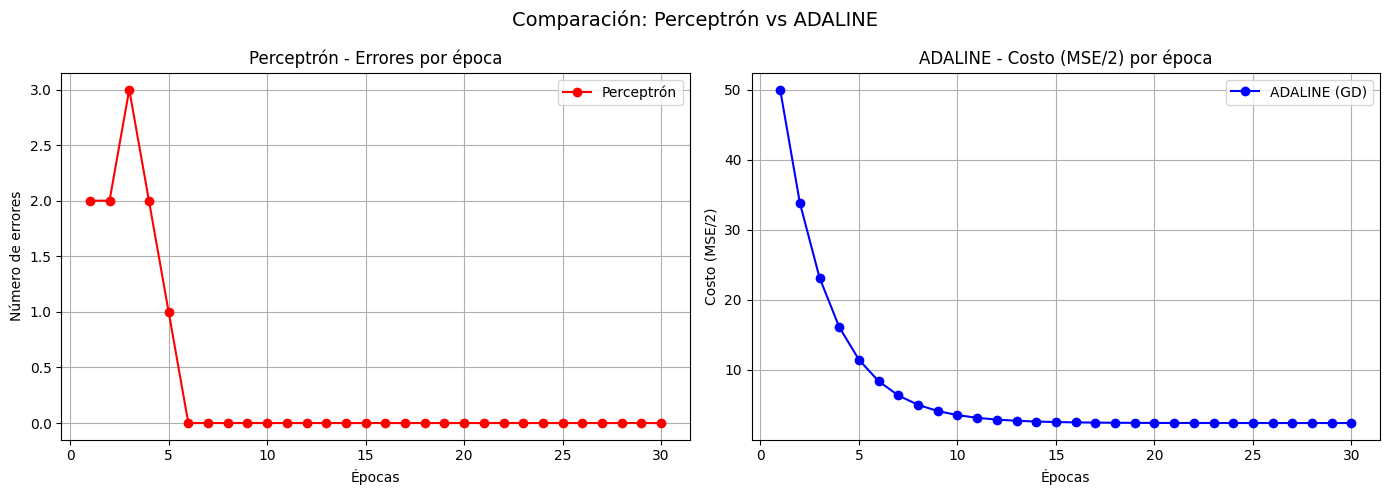

In [ ]:
# Importar Perceptrón del notebook anterior (redefinir)
class Perceptron:
    def __init__(self, eta=0.1, n_iter=50):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w_ = np.zeros(1 + X.shape[1])
        self.errors_ = []
        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                update = self.eta * (target - prediction)
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

# Datos originales (sin estandarizar) para perceptrón
ppn = Perceptron(eta=0.1, n_iter=30)
ppn.fit(X, y)

# ADALINE con datos estandarizados
sc = StandardScaler()
X_std = sc.fit_transform(X)
ada = AdalineGD(eta=0.01, n_iter=30)
ada.fit(X_std, y)

# Tabla comparativa (como texto/impresión)
print("=" * 60)
print(f"{'Comparación: Perceptrón vs ADALINE':^60}")
print("=" * 60)
print(f"{'Característica':<30} {'Perceptrón':<15} {'ADALINE':<15}")
print("-" * 60)
print(f"{'Función de activación':<30} {'Escalón':<15} {'Lineal (GD)':<15}")
print(f"{'Regla de aprendizaje':<30} {'Perceptrón':<15} {'Delta/LMS':<15}")
print(f"{'Función de costo':<30} {'Errores':<15} {'MSE':<15}")
print(f"{'Método optimización':<30} {'N/A':<15} {'Gradiente desc.':<15}")
print(f"{'Errores finales (Perceptrón)':<30} {ppn.errors_[-1]:<15}")
print(f"{'Costo final (ADALINE)':<30} {'':15} {ada.cost_[-1]:<15.4f}")
print("=" * 60)

# Gráfica comparativa de convergencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ppn.errors_) + 1), ppn.errors_,
            marker='o', color='red', label='Perceptrón')
axes[0].set_title('Perceptrón - Errores por época')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Número de errores')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, len(ada.cost_) + 1), ada.cost_,
            marker='o', color='blue', label='ADALINE (GD)')
axes[1].set_title('ADALINE - Costo (MSE/2) por época')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Costo (MSE/2)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Comparación: Perceptrón vs ADALINE', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/adaline_vs_perceptron.png', dpi=100, bbox_inches='tight')
plt.show()

## Referencias Bibliográficas

1. **Widrow, B., & Hoff, M. E. (1960)**. Adaptive Switching Circuits. *IRE WESCON Convention Record*, 4, 96-104.
   - Artículo original donde se presenta ADALINE y la regla LMS.

2. **Haykin, S. (2009)**. *Neural Networks and Learning Machines* (3rd ed.). Pearson.
   - Capítulo 3: Single-Layer Perceptrons — análisis profundo de ADALINE y la regla LMS.

3. **Raschka, S., & Mirjalili, V. (2019)**. *Python Machine Learning* (3rd ed.). Packt Publishing.
   - Capítulo 2: Training Simple Machine Learning Algorithms for Classification — implementación práctica de ADALINE.

4. **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. *Deep Learning*. MIT Press.
   - Capítulo 4: Numerical Computation — descenso de gradiente y optimización.
   - Disponible en: https://www.deeplearningbook.org/

5. **Rosenblatt, F. (1958)**. The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain. *Psychological Review*, 65(6), 386-408.
   - Artículo original del Perceptrón, antecedente directo de ADALINE.

6. **Widrow, B., & Lehr, M. A. (1990)**. 30 Years of Adaptive Neural Networks: Perceptron, Madaline, and Backpropagation. *Proceedings of the IEEE*, 78(9), 1415-1442.
   - Revisión histórica de ADALINE y sus extensiones (MADALINE).

7. **Scikit-learn Documentation**. *StandardScaler*. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
   - Documentación oficial sobre estandarización de características.